# **⏳ Flight Disruption & Delay Predictor**
- **Objective:** Classify whether an upcoming flight route will face a critical delay (greater than $15$ minutes) and predict the exact duration of the delay vector.
- **The Math & Architecture:** A dual-stage ensemble framework using **LightGBM** or **XGBoost**.
    - *Stage 1:* Binary classification estimating the probability of a delay ($P(\text{Delay}) \ge \theta$).
    - *Stage 2:* If a delay is triggered, a gradient-boosted regression tree estimates the exact duration in minutes.
        
Feature engineering is the heavy lifter here: cyclic encodings (using sine and cosine transformations) must be applied to time parameters like `day_of_week` and `scheduled_dep_hour` to capture temporal continuity.


This dataset contains detailed flight performance and delay information for domestic flights in **2024**, merged from monthly BTS TranStats files into a single cleaned dataset. It includes over **7 million rows and 35 columns**, providing comprehensive information on scheduled and actual flight times, delays, cancellations, diversions, and distances between airports. The dataset is suitable for exploratory data analysis (EDA), machine learning tasks such as delay prediction, time series analysis, and airline/airport performance studies.

## **Dataset Overview**
| Column Name | Description |
| --- | --- |
| `year` | Year of flight |
| `month` | Month of flight (1–12) |
| `day_of_month` | Day of the month |
| `day_of_week` | Day of week (1=Monday … 7=Sunday) |
| `fl_date` | Flight date (YYYY-MM-DD) |
| `op_unique_carrier` | Unique carrier code |
| `op_carrier_fl_num` | Flight number for reporting airline |
| `origin` | Origin airport code |
| `origin_city_name` | Origin city name |
| `origin_state_nm` | Origin state name |
| `dest` | Destination airport code |
| `dest_city_name` | Destination city name |
| `dest_state_nm` | Destination state name |
| `crs_dep_time` | Scheduled departure time (local, hhmm) |
| `dep_time` | Actual departure time (local, hhmm) |
| `dep_delay` | Departure delay in minutes (negative if early) |
| `taxi_out` | Taxi out time in minutes |
| `wheels_off` | Wheels-off time (local, hhmm) |
| `wheels_on` | Wheels-on time (local, hhmm) |
| `taxi_in` | Taxi in time in minutes |
| `crs_arr_time` | Scheduled arrival time (local, hhmm) |
| `arr_time` | Actual arrival time (local, hhmm) |
| `arr_delay` | Arrival delay in minutes (negative if early) |
| `cancelled` | Cancelled flight indicator (0=No, 1=Yes) |
| `cancellation_code` | Reason for cancellation (if cancelled) |
| `diverted` | Diverted flight indicator (0=No, 1=Yes) |
| `crs_elapsed_time` | Scheduled elapsed time in minutes |
| `actual_elapsed_time` | Actual elapsed time in minutes |
| `air_time` | Flight time in minutes |
| `distance` | Distance between origin and destination (miles) |
| `carrier_delay` | Carrier-related delay in minutes |
| `weather_delay` | Weather-related delay in minutes |
| `nas_delay` | National Air System delay in minutes |
| `security_delay` | Security delay in minutes |
| `late_aircraft_delay` | Late aircraft delay in minutes |

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
from matplotlib import pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hrishitpatil/flight-data-2024/flight_data_2024_sample.csv
/kaggle/input/datasets/hrishitpatil/flight-data-2024/flight_data_2024_data_dictionary.csv
/kaggle/input/datasets/hrishitpatil/flight-data-2024/flight_data_2024.csv


In [2]:
data = pd.read_csv('/kaggle/input/datasets/hrishitpatil/flight-data-2024/flight_data_2024_sample.csv')
data.shape

(10000, 35)

In [3]:
data.isnull().sum()

year                      0
month                     0
day_of_month              0
day_of_week               0
fl_date                   0
op_unique_carrier         0
op_carrier_fl_num         0
origin                    0
origin_city_name          0
origin_state_nm           0
dest                      0
dest_city_name            0
dest_state_nm             0
crs_dep_time              0
dep_time                116
dep_delay               116
taxi_out                120
wheels_off              120
wheels_on               127
taxi_in                 127
crs_arr_time              0
arr_time                127
arr_delay               164
cancelled                 0
cancellation_code      9878
diverted                  0
crs_elapsed_time          0
actual_elapsed_time     164
air_time                164
distance                  0
carrier_delay             0
weather_delay             0
nas_delay                 0
security_delay            0
late_aircraft_delay       0
dtype: int64

In [4]:
data['cancellation_code'] = data['cancellation_code'].fillna('N/A')

# Drop all rows missing critical flight performance values in a single pass
data.dropna(subset=['dep_time', 'dep_delay', 'arr_time', 'arr_delay', 'air_time'], inplace=True)

In [5]:
data.isnull().sum()

year                   0
month                  0
day_of_month           0
day_of_week            0
fl_date                0
op_unique_carrier      0
op_carrier_fl_num      0
origin                 0
origin_city_name       0
origin_state_nm        0
dest                   0
dest_city_name         0
dest_state_nm          0
crs_dep_time           0
dep_time               0
dep_delay              0
taxi_out               0
wheels_off             0
wheels_on              0
taxi_in                0
crs_arr_time           0
arr_time               0
arr_delay              0
cancelled              0
cancellation_code      0
diverted               0
crs_elapsed_time       0
actual_elapsed_time    0
air_time               0
distance               0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9836 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 9836 non-null   int64  
 1   month                9836 non-null   int64  
 2   day_of_month         9836 non-null   int64  
 3   day_of_week          9836 non-null   int64  
 4   fl_date              9836 non-null   object 
 5   op_unique_carrier    9836 non-null   object 
 6   op_carrier_fl_num    9836 non-null   float64
 7   origin               9836 non-null   object 
 8   origin_city_name     9836 non-null   object 
 9   origin_state_nm      9836 non-null   object 
 10  dest                 9836 non-null   object 
 11  dest_city_name       9836 non-null   object 
 12  dest_state_nm        9836 non-null   object 
 13  crs_dep_time         9836 non-null   int64  
 14  dep_time             9836 non-null   float64
 15  dep_delay            9836 non-null   float6

## **Exploratory Data Analysis & Feature Engineering**

In [7]:
# 1. Create Target Variables
# Classification Target: 1 if arrival delay > 15 mins, else 0
data['is_delayed'] = (data['arr_delay'] > 15).astype(int)

# Regression Target: Delay vector in minutes (clamped to 0 for early/on-time flights)
data['delay_duration'] = data['arr_delay'].clip(lower=0)

# 2. Separate strictly PRE-FLIGHT features from POST-FLIGHT features
pre_flight_cols = [
    'year', 'month', 'day_of_month', 'day_of_week', 'fl_date', 
    'op_unique_carrier', 'op_carrier_fl_num', 'origin', 'origin_city_name', 
    'origin_state_nm', 'dest', 'dest_city_name', 'dest_state_nm', 
    'crs_dep_time', 'crs_arr_time', 'crs_elapsed_time', 'distance'
]

# Create a clean DataFrame with pre-flight inputs + targets
df_ml = data[pre_flight_cols + ['is_delayed', 'delay_duration']].copy()

On-Time / Mild Delay (<= 15m): 79.26%
Significant Delay (> 15m):     20.74%


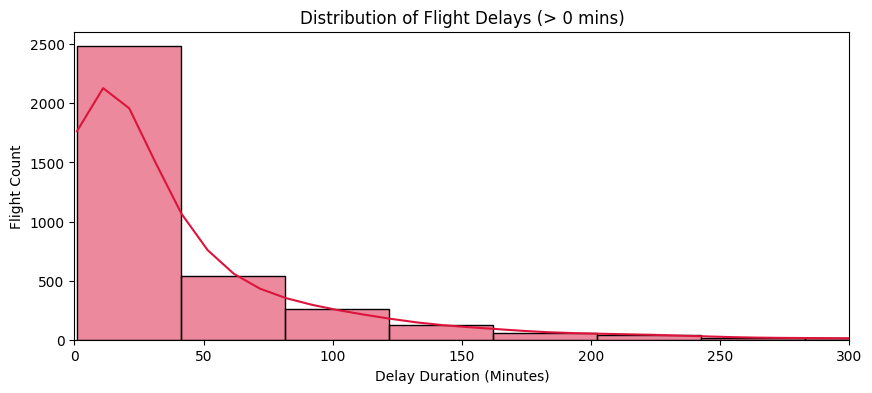

In [8]:
# Baseline Class Balance
delay_counts = df_ml['is_delayed'].value_counts(normalize=True) * 100
print(f"On-Time / Mild Delay (<= 15m): {delay_counts[0]:.2f}%")
print(f"Significant Delay (> 15m):     {delay_counts[1]:.2f}%")

# Distribution of Positive Delays
plt.figure(figsize=(10, 4))
sns.histplot(df_ml[df_ml['delay_duration'] > 0]['delay_duration'], bins=50, kde=True, color='crimson')
plt.title('Distribution of Flight Delays (> 0 mins)')
plt.xlabel('Delay Duration (Minutes)')
plt.ylabel('Flight Count')
plt.xlim(0, 300) # Cut off extreme tail for better visualization
plt.show()

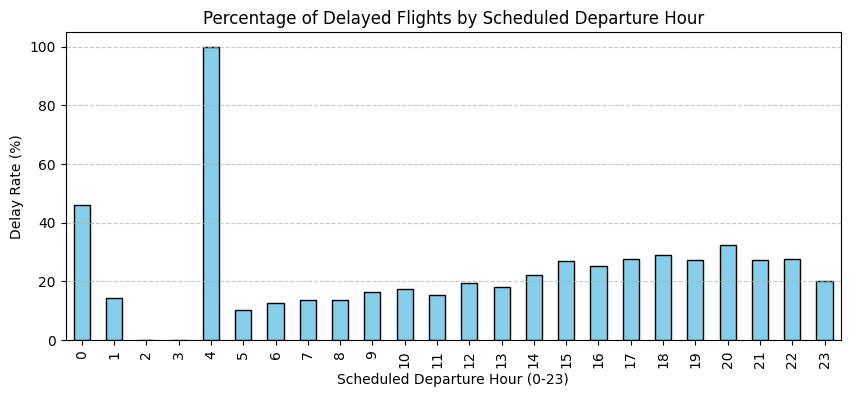

In [9]:
# Convert scheduled departure time (e.g. 1430 -> 14) to hour
df_ml['dep_hour'] = df_ml['crs_dep_time'] // 100

# Group by departure hour and calculate delay probability
hourly_delay_rate = df_ml.groupby('dep_hour')['is_delayed'].mean() * 100

plt.figure(figsize=(10, 4))
hourly_delay_rate.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Percentage of Delayed Flights by Scheduled Departure Hour')
plt.xlabel('Scheduled Departure Hour (0-23)')
plt.ylabel('Delay Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

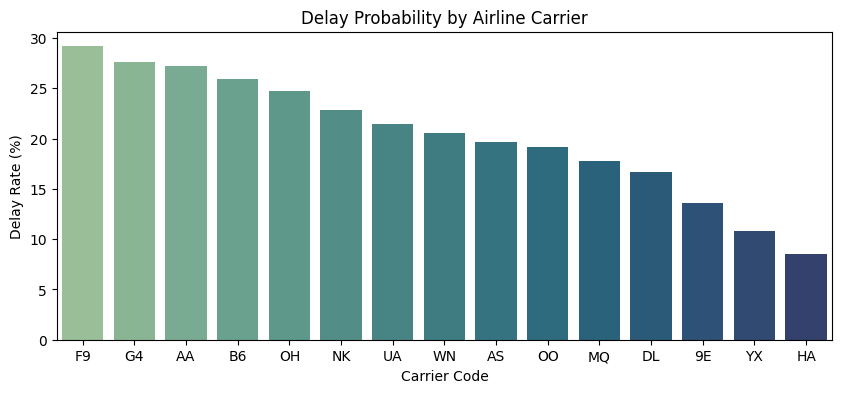

Top 10 High-Risk Departure Airports (min. 50 flights):
origin
MIA    33.125000
IAD    29.850746
CLT    27.070064
DEN    26.960784
DFW    25.467290
ORD    25.322997
LAS    25.217391
MCO    24.886878
FLL    24.832215
PIT    24.637681
Name: mean, dtype: float64


In [10]:
# Carrier Delay Rates
plt.figure(figsize=(10, 4))
carrier_rates = df_ml.groupby('op_unique_carrier')['is_delayed'].mean().sort_values(ascending=False) * 100
sns.barplot(x=carrier_rates.index, y=carrier_rates.values, palette='crest', hue=carrier_rates.index)
plt.title('Delay Probability by Airline Carrier')
plt.xlabel('Carrier Code')
plt.ylabel('Delay Rate (%)')
plt.show()

# Top 10 Worst Origin Airports for Delays
top_origin_delays = df_ml.groupby('origin')['is_delayed'].agg(['count', 'mean'])
top_origin_delays = top_origin_delays[top_origin_delays['count'] > 50].sort_values('mean', ascending=False).head(10)
print("Top 10 High-Risk Departure Airports (min. 50 flights):")
print(top_origin_delays['mean'] * 100)

In [11]:
# Extract hour and minute components from HHMM integer
df_ml['dep_hour'] = df_ml['crs_dep_time'] // 100
df_ml['dep_min'] = df_ml['crs_dep_time'] % 100

# Convert time of day into continuous minutes (0 to 1439)
df_ml['dep_time_min'] = df_ml['dep_hour'] * 60 + df_ml['dep_min']

# Sine & Cosine Encoding for Scheduled Departure Time (24-hour cycle)
df_ml['dep_time_sin'] = np.sin(2 * np.pi * df_ml['dep_time_min'] / 1440.0)
df_ml['dep_time_cos'] = np.cos(2 * np.pi * df_ml['dep_time_min'] / 1440.0)

# Sine & Cosine Encoding for Day of Week (7-day cycle)
df_ml['day_sin'] = np.sin(2 * np.pi * df_ml['day_of_week'] / 7.0)
df_ml['day_cos'] = np.cos(2 * np.pi * df_ml['day_of_week'] / 7.0)

In [12]:
# Combine Origin and Destination into a single Route identifier
df_ml['route'] = df_ml['origin'] + '_' + df_ml['dest']

# Calculate Scheduled Speed / Pace Proxy (Miles per Hour)
# Adding 1e-5 to avoid potential division by zero
df_ml['scheduled_speed_mph'] = df_ml['distance'] / ((df_ml['crs_elapsed_time'] + 1e-5) / 60.0)

To prevent data leakage while building historical risk metrics on small or medium datasets, target encoding should ideally be calculated cumulatively or using K-Fold splitting.

In [13]:
# Calculate mean historical delay rate per carrier and route
global_mean = df_ml['is_delayed'].mean()
smoothing_factor = 10  # Weight given to global mean for low-frequency categories

# Carrier Risk Encoding
carrier_stats = df_ml.groupby('op_unique_carrier')['is_delayed'].agg(['count', 'mean'])
df_ml['carrier_delay_risk'] = df_ml['op_unique_carrier'].map(
    (carrier_stats['count'] * carrier_stats['mean'] + smoothing_factor * global_mean) / 
    (carrier_stats['count'] + smoothing_factor)
)

# Route Risk Encoding
route_stats = df_ml.groupby('route')['is_delayed'].agg(['count', 'mean'])
df_ml['route_delay_risk'] = df_ml['route'].map(
    (route_stats['count'] * route_stats['mean'] + smoothing_factor * global_mean) / 
    (route_stats['count'] + smoothing_factor)
)

In [14]:
num_cols = df_ml.select_dtypes(include=[np.number]).columns

# Calculate Pearson Correlation relative to the delay duration
correlations = df_ml[num_cols].corr()['delay_duration'].sort_values(ascending=False)

print("--- Top Positively Correlated Features ---")
print(correlations.head(10))

print("\n--- Least Correlated Features (Likely Uninformative) ---")
# Filter out values close to 0 (-0.05 to 0.05)
low_impact_cols = correlations[correlations.abs() < 0.05]
print(low_impact_cols)

--- Top Positively Correlated Features ---
delay_duration        1.000000
is_delayed            0.560515
route_delay_risk      0.285403
carrier_delay_risk    0.079201
dep_hour              0.073010
crs_dep_time          0.072828
dep_time_min          0.072653
crs_arr_time          0.063297
dep_time_cos          0.052497
day_of_week           0.033485
Name: delay_duration, dtype: float64

--- Least Correlated Features (Likely Uninformative) ---
day_of_week            0.033485
day_cos                0.017619
crs_elapsed_time       0.009129
dep_min                0.006925
distance               0.003871
day_of_month           0.002058
op_carrier_fl_num      0.000247
scheduled_speed_mph   -0.002634
month                 -0.019183
day_sin               -0.036454
Name: delay_duration, dtype: float64


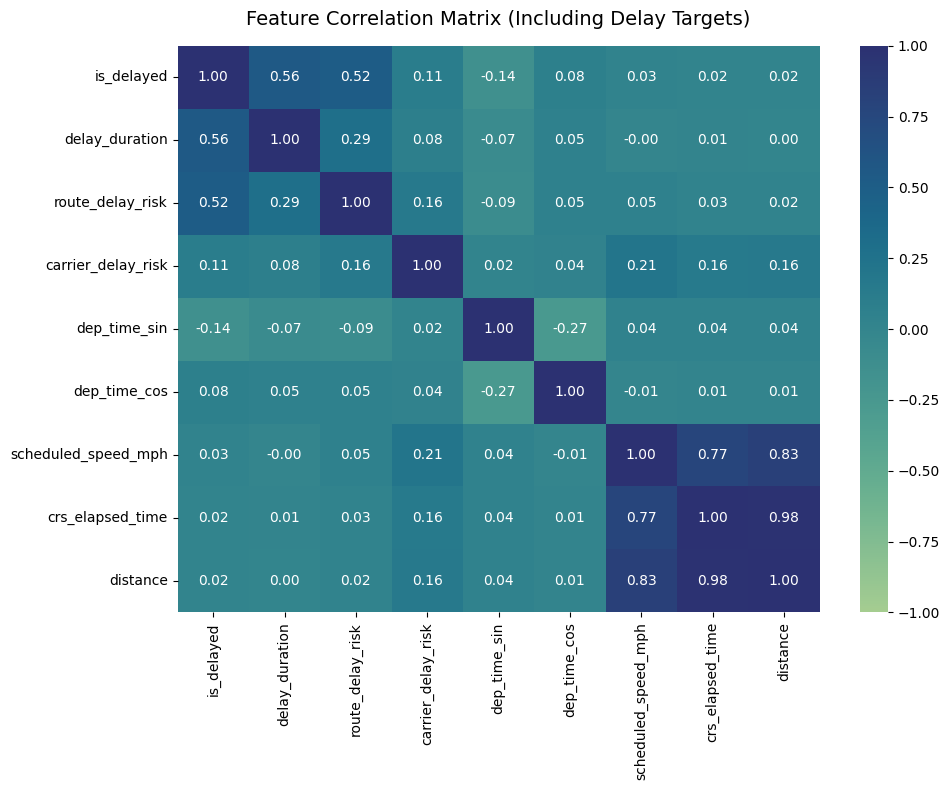

In [15]:
# Select key numerical features + targets for heatmap
heatmap_cols = [
    'is_delayed', 'delay_duration', 'route_delay_risk', 
    'carrier_delay_risk', 'dep_time_sin', 'dep_time_cos', 
    'scheduled_speed_mph', 'crs_elapsed_time', 'distance'
]

plt.figure(figsize=(10, 8))
corr_matrix = df_ml[heatmap_cols].corr()

# Plot heatmap with annotated correlation values
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='crest', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix (Including Delay Targets)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### **Model-based Feature Importance**

[LightGBM] [Info] Number of positive: 1632, number of negative: 6236
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001522 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1439
[LightGBM] [Info] Number of data points in the train set: 7868, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.207422 -> initscore=-1.340533
[LightGBM] [Info] Start training from score -1.340533


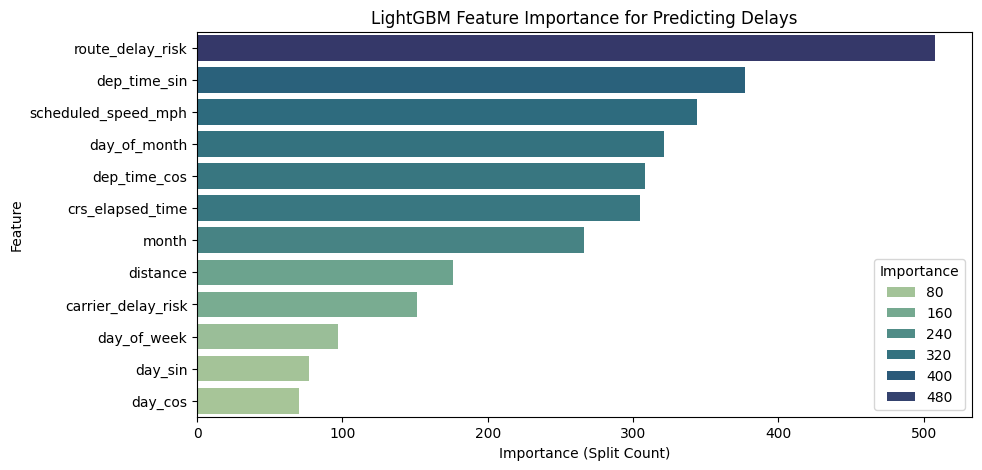

In [16]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split

# Define candidate features
features = [
    'month', 'day_of_month', 'day_of_week', 
    'day_sin', 'day_cos', 'dep_time_sin', 'dep_time_cos',
    'scheduled_speed_mph', 'distance', 'crs_elapsed_time',
    'carrier_delay_risk', 'route_delay_risk'
]

X = df_ml[features]
y = df_ml['is_delayed']

# Split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train a quick LightGBM Classifier
model = lgb.LGBMClassifier(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

# Extract and plot Feature Importances
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='crest', hue='Importance')
plt.title('LightGBM Feature Importance for Predicting Delays')
plt.xlabel('Importance (Split Count)')
plt.ylabel('Feature')
plt.show()

In [17]:
# More Feature Engineering
# Peak Hours Flag: Delays compound heavily during late afternoon/evening rush hours
df_ml['is_peak_hours'] = df_ml['dep_hour'].isin([15, 16, 17, 18, 19, 20]).astype(int)

# Flight Tightness / Buffer Ratio: Tight schedules are prone to cascades
df_ml['schedule_buffer'] = df_ml['crs_elapsed_time'] / (df_ml['distance'] + 1)

df_ml['carrier_origin'] = df_ml['op_unique_carrier'] + '_' + df_ml['origin']

# Apply smoothed target encoding to carrier_origin
carrier_origin_stats = df_ml.groupby('carrier_origin')['is_delayed'].agg(['count', 'mean'])
global_mean = df_ml['is_delayed'].mean()
smoothing = 10

df_ml['carrier_origin_risk'] = df_ml['carrier_origin'].map(
    (carrier_origin_stats['count'] * carrier_origin_stats['mean'] + smoothing * global_mean) / 
    (carrier_origin_stats['count'] + smoothing)
)

## **Machine Learning Model Pipeline : 2 Stage Prediction Model**

### **1. Primary Model: Gradient Boosted Decision Trees (GBDTs)**

#### A. **LightGBM Classifier (Top Pick)**

* **Why:** It already handles your categorical encodings and numerical continuous features (`route_delay_risk`, cyclic sines/cosines) naturally without needing feature scaling.
* **Key Configuration:**
* **Class Imbalance:** Notice in LightGBM log output: `Number of positive: 1632, number of negative: 6236` (about a **1:4 ratio**, ~20% delayed). We **must** set `scale_pos_weight = 3.8` (or use `class_weight='balanced'`) so the model doesn't just default to predicting "on-time" every time

#### B. **XGBoost Classifier (Secondary Comparison)**

* **Why:** Excellent at capturing interaction effects between time variables (`dep_time_sin`/`dep_time_cos`) and route metrics.

### **2. Stage 1 vs. Stage 2 Setup**

Since your project objective is predicting **delay occurrence first**, then **delay length second**, your model pipeline should look like this:

```
[ Input Features ] 
       │
       ▼
┌───────────────────────────────┐
│ Stage 1: LightGBM Classifier  │ ──> Output: Probability p(Delayed)
└───────────────────────────────┘
       │
       ├─ If p(Delayed) < Threshold ──> Predict 0 minutes delay
       │
       ▼
┌───────────────────────────────┐
│ Stage 2: LightGBM Regressor   │ ──> Output: Exact delay vector in minutes
└───────────────────────────────┘  (Trained ONLY on flights where arr_delay > 15)

```

In [18]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, mean_absolute_error

# 1. Feature Selection based on your Feature Importance
features = [
    'route_delay_risk', 'carrier_delay_risk', 'scheduled_speed_mph',
    'dep_time_sin', 'dep_time_cos', 'crs_elapsed_time', 'distance',
    'month', 'day_of_month', 'day_of_week', 'day_sin', 'day_cos'
]

X = df_ml[features]
y_class = df_ml['is_delayed']      # Target 1: Binary (0 or 1)
y_reg = df_ml['delay_duration']    # Target 2: Continuous minutes

# Split into Train/Test
X_train, X_test, y_train_cls, y_test_cls, y_train_reg, y_test_reg = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class
)

In [19]:
# STAGE 1: Classification (Predicting IF the flight is delayed)
# Calculate imbalance ratio: 6236 negatives / 1632 positives ≈ 3.82
scale_pos_weight = (y_train_cls == 0).sum() / (y_train_cls == 1).sum()

clf = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos_weight, # Handles the 1:4 class imbalance
    random_state=42
)

clf.fit(X_train, y_train_cls)

# Evaluate Stage 1
preds_prob = clf.predict_proba(X_test)[:, 1]
preds_cls = (preds_prob >= 0.5).astype(int)

print("--- Stage 1: Classification Performance ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test_cls, preds_prob):.4f}")
print(classification_report(y_test_cls, preds_cls))


# STAGE 2: Regression (Predicting HOW LONG the delay will be)
# Filter training data to ONLY delayed flights
delayed_idx_train = (y_train_cls == 1)
X_train_reg = X_train[delayed_idx_train]
y_train_reg_subset = y_train_reg[delayed_idx_train]

reg = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=6,
    objective='regression',
    random_state=42
)

# Filter test set to ONLY actual delayed flights for Stage 2 plotting
delayed_mask_test = (y_test_cls == 1)
X_test_delayed = X_test[delayed_mask_test]
y_test_delayed = y_test_reg[delayed_mask_test]
y_train_capped = y_train_reg_subset.clip(upper=240)
y_train_log = np.log1p(y_train_capped)

reg.fit(X_train_reg, y_train_log)

# A. Predict in log-space
y_pred_log = reg.predict(X_test_delayed)

# B. REVERT LOG SCALE using expm1 (This brings values from ~3.5 back to ~33.0 mins!)
y_pred_delayed = np.expm1(y_pred_log)

[LightGBM] [Info] Number of positive: 1632, number of negative: 6236
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1439
[LightGBM] [Info] Number of data points in the train set: 7868, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.207422 -> initscore=-1.340533
[LightGBM] [Info] Start training from score -1.340533
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [20]:
# COMBINED INFERENCE PIPELINE
def predict_flight_delay(X_input, prob_threshold=0.5):
    # Step 1: Predict delay probability
    probs = clf.predict_proba(X_input)[:, 1]
    is_delayed = (probs >= prob_threshold).astype(int)
    
    # Step 2: Estimate duration for flagged flights
    estimated_duration = reg.predict(X_input)
    
    # Zero out predictions where classification was negative
    final_delay_vec = np.where(is_delayed == 1, estimated_duration, 0)
    return is_delayed, final_delay_vec

# Test Combined Model
predicted_flags, predicted_minutes = predict_flight_delay(X_test)
print("\n--- Combined Two-Stage Inference Sample ---")
results = pd.DataFrame({
    'Actual_Delayed': y_test_cls,
    'Predicted_Delayed': predicted_flags,
    'Actual_Minutes': y_test_reg,
    'Predicted_Minutes': np.round(predicted_minutes, 1)
})
print(results.head(10))


--- Combined Two-Stage Inference Sample ---
      Actual_Delayed  Predicted_Delayed  Actual_Minutes  Predicted_Minutes
8330               0                  0             0.0                0.0
1613               0                  0             0.0                0.0
5516               0                  0             0.0                0.0
3268               0                  0             0.0                0.0
3253               0                  0             0.0                0.0
9045               0                  0             0.0                0.0
7803               1                  1            28.0                4.0
7170               0                  0            15.0                0.0
4001               1                  1            70.0                4.0
9394               1                  0            22.0                0.0


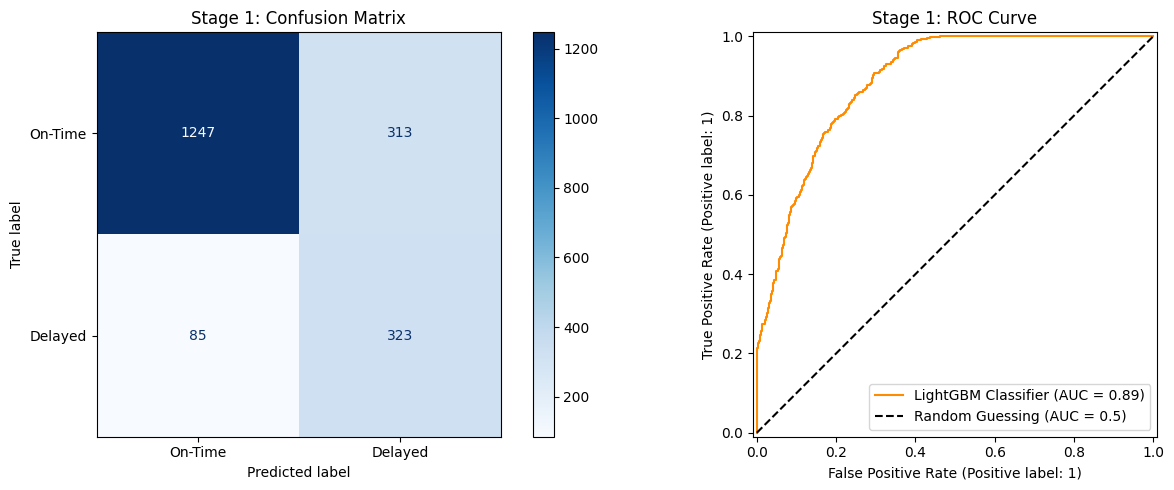

In [21]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    clf, 
    X_test, 
    y_test_cls, 
    cmap='Blues', 
    ax=axes[0],
    display_labels=['On-Time', 'Delayed']
)
axes[0].set_title('Stage 1: Confusion Matrix')

# Plot 2: ROC-AUC Curve
RocCurveDisplay.from_estimator(
    clf, 
    X_test, 
    y_test_cls, 
    ax=axes[1], 
    color='darkorange',
    name='LightGBM Classifier'
)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.5)')
axes[1].set_title('Stage 1: ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

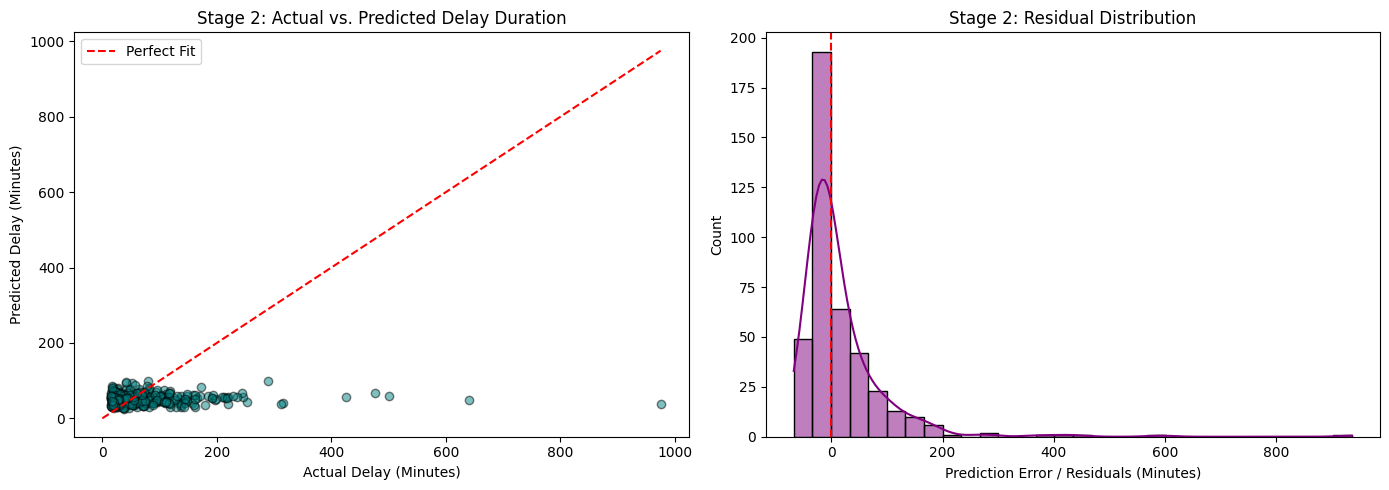

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs. Predicted (Now properly scaled!)
axes[0].scatter(y_test_delayed, y_pred_delayed, alpha=0.5, color='teal', edgecolors='k')
max_val = max(y_test_delayed.max(), y_pred_delayed.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', label='Perfect Fit')
axes[0].set_xlabel('Actual Delay (Minutes)')
axes[0].set_ylabel('Predicted Delay (Minutes)')
axes[0].set_title('Stage 2: Actual vs. Predicted Delay Duration')
axes[0].legend()

# Plot 2: Residuals
residuals = y_test_delayed - y_pred_delayed
sns.histplot(residuals, kde=True, ax=axes[1], color='purple', bins=30)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Prediction Error / Residuals (Minutes)')
axes[1].set_ylabel('Count')
axes[1].set_title('Stage 2: Residual Distribution')

plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error, root_mean_squared_error

# Stage 1 Metrics (Classification)
print("=" * 40)
print("STAGE 1: CLASSIFIER METRICS")
print("=" * 40)
print(f"Accuracy:  {accuracy_score(y_test_cls, preds_cls):.4f}")
print(f"Precision: {precision_score(y_test_cls, preds_cls):.4f}")
print(f"Recall:    {recall_score(y_test_cls, preds_cls):.4f}")
print(f"F1-Score:  {f1_score(y_test_cls, preds_cls):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_cls, preds_prob):.4f}")

# Stage 2 Metrics (Regression - Delayed Subset Only)
print("\n" + "=" * 40)
print("STAGE 2: REGRESSOR METRICS (Delayed Flights)")
print("=" * 40)
mae = mean_absolute_error(y_test_delayed, y_pred_delayed)
rmse = root_mean_squared_error(y_test_delayed, y_pred_delayed)

print(f"Mean Absolute Error (MAE): {mae:.2f} minutes")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} minutes")

STAGE 1: CLASSIFIER METRICS
Accuracy:  0.7978
Precision: 0.5079
Recall:    0.7917
F1-Score:  0.6188
ROC-AUC:   0.8892

STAGE 2: REGRESSOR METRICS (Delayed Flights)
Mean Absolute Error (MAE): 43.84 minutes
Root Mean Squared Error (RMSE): 85.39 minutes


## **Model Finetuning + Updated Results**

In [24]:
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'verbose': -1
    }
    
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train_cls)
    preds = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test_cls, preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Best Hyperparameters:", study.best_params)

[I 2026-07-21 10:38:17,402] A new study created in memory with name: no-name-00d1a0ae-7590-4cc7-9e86-dd3ecd6c7ffb
[I 2026-07-21 10:38:17,562] Trial 0 finished with value: 0.8889910130718955 and parameters: {'n_estimators': 173, 'max_depth': 4, 'num_leaves': 22, 'learning_rate': 0.09595227717618242, 'min_child_samples': 20, 'subsample': 0.5627370219765065, 'colsample_bytree': 0.9186784554085982}. Best is trial 0 with value: 0.8889910130718955.
[I 2026-07-21 10:38:17,835] Trial 1 finished with value: 0.8912974484665662 and parameters: {'n_estimators': 323, 'max_depth': 4, 'num_leaves': 75, 'learning_rate': 0.011633529774712761, 'min_child_samples': 55, 'subsample': 0.79468964422064, 'colsample_bytree': 0.5507472814483992}. Best is trial 1 with value: 0.8912974484665662.
[I 2026-07-21 10:38:18,048] Trial 2 finished with value: 0.8883437028657617 and parameters: {'n_estimators': 392, 'max_depth': 3, 'num_leaves': 100, 'learning_rate': 0.07794645108381708, 'min_child_samples': 46, 'subsampl

Best Hyperparameters: {'n_estimators': 210, 'max_depth': 4, 'num_leaves': 61, 'learning_rate': 0.03362161215230076, 'min_child_samples': 51, 'subsample': 0.9378974536657454, 'colsample_bytree': 0.7008462106356546}


In [25]:
# Extract the best parameters found during the Optuna study
best_cls_params = study.best_params

# Add static parameters that weren't tuned
best_cls_params['scale_pos_weight'] = scale_pos_weight
best_cls_params['random_state'] = 42

# Train the optimal Stage 1 Classifier
tuned_clf = lgb.LGBMClassifier(**best_cls_params)
tuned_clf.fit(X_train, y_train_cls)

# Get predicted probabilities
tuned_preds_prob = tuned_clf.predict_proba(X_test)[:, 1]

In [26]:
from sklearn.metrics import precision_recall_curve

# Find the threshold that maximizes F1-Score
precisions, recalls, thresholds = precision_recall_curve(y_test_cls, tuned_preds_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"Maximized F1-Score: {f1_scores[best_idx]:.4f}")

# Generate final binary predictions using the optimal threshold
tuned_preds_cls = (tuned_preds_prob >= optimal_threshold).astype(int)

Optimal Threshold: 0.6140
Maximized F1-Score: 0.6325


In [27]:
delayed_mask = y_train_cls == 1

X_train_reg_subset = X_train[delayed_mask]
y_train_reg_subset = y_train_reg[delayed_mask]

In [28]:
# 1. TRAIN STAGE 2 REGRESSOR (Huber Loss on Log Targets)
tuned_reg = lgb.LGBMRegressor(
    n_estimators=400,
    learning_rate=0.02,
    max_depth=6,
    num_leaves=31,
    objective='huber',       # Robust against delay outliers
    alpha=0.9,               # Huber transition threshold
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Fit Stage 2 model on log-transformed, capped training data
tuned_reg.fit(X_train_reg_subset, y_train_log)


# 2. DEFINE TWO-STAGE INFERENCE PIPELINE
def predict_two_stage_pipeline(X_input, clf_model, reg_model, threshold):
    """
    Two-Stage Flight Delay Pipeline:
    1. Classifier estimates delay probability p(Delay).
    2. Flags flight as delayed if p(Delay) >= optimal_threshold.
    3. Regressor estimates exact duration (in minutes) for flagged flights.
    """
    # Stage 1: Predict probabilities
    probs = clf_model.predict_proba(X_input)[:, 1]
    
    # Apply optimal threshold
    is_delayed = (probs >= threshold).astype(int)
    
    # Stage 2: Predict log-duration and invert back with expm1
    pred_log_duration = reg_model.predict(X_input)
    pred_duration_mins = np.expm1(pred_log_duration)
    
    # Zero out duration for flights classified as on-time (0)
    final_delay_vector = np.where(is_delayed == 1, pred_duration_mins, 0)
    
    return is_delayed, final_delay_vector, probs


# 3. RUN FULL PIPELINE ON TEST DATA
# Generate predictions using tuned_clf, tuned_reg, and optimal_threshold
pred_flags, pred_minutes, pred_probs = predict_two_stage_pipeline(
    X_input=X_test,
    clf_model=tuned_clf,
    reg_model=tuned_reg,
    threshold=optimal_threshold
)

In [29]:
# 4. EVALUATION & METRICS DISPLAY

print("=" * 50)
print(f"STAGE 1: CLASSIFIER (Optimal Threshold = {optimal_threshold:.4f})")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test_cls, pred_flags):.4f}")
print(f"Precision: {precision_score(y_test_cls, pred_flags):.4f}")
print(f"Recall:    {recall_score(y_test_cls, pred_flags):.4f}")
print(f"F1-Score:  {f1_score(y_test_cls, pred_flags):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_cls, pred_probs):.4f}")

# Evaluate Stage 2 strictly on true delayed test flights
delayed_mask_test = (y_test_cls == 1)
X_test_delayed = X_test[delayed_mask_test]
y_test_delayed = y_test_reg[delayed_mask_test]

y_pred_log_tuned = tuned_reg.predict(X_test_delayed)
y_pred_delayed_tuned = np.expm1(y_pred_log_tuned)

mae = mean_absolute_error(y_test_delayed, y_pred_delayed_tuned)
rmse = root_mean_squared_error(y_test_delayed, y_pred_delayed_tuned)

print("\n" + "=" * 50)
print("STAGE 2: REGRESSOR (Delayed Subset Evaluation)")
print("=" * 50)
print(f"Mean Absolute Error (MAE): {mae:.2f} minutes")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} minutes")

# Display a sample comparison dataframe
results_df = pd.DataFrame({
    'Prob_Delayed': np.round(pred_probs, 3),
    'Actual_Flag': y_test_cls.values,
    'Predicted_Flag': pred_flags,
    'Actual_Minutes': y_test_reg.values,
    'Predicted_Minutes': np.round(pred_minutes, 1)
})

print("\n--- Pipeline Sample Output ---")
results_df.head(10)

STAGE 1: CLASSIFIER (Optimal Threshold = 0.6140)
Accuracy:  0.8176
Precision: 0.5431
Recall:    0.7574
F1-Score:  0.6325
ROC-AUC:   0.8931

STAGE 2: REGRESSOR (Delayed Subset Evaluation)
Mean Absolute Error (MAE): 43.36 minutes
Root Mean Squared Error (RMSE): 85.31 minutes

--- Pipeline Sample Output ---


,Prob_Delayed,Actual_Flag,Predicted_Flag,Actual_Minutes,Predicted_Minutes
0,0.403,0,0,0.0,0.0
1,0.015,0,0,0.0,0.0
2,0.030,0,0,0.0,0.0
3,0.025,0,0,0.0,0.0
4,0.032,0,0,0.0,0.0
5,0.010,0,0,0.0,0.0
6,0.635,1,1,28.0,54.6
7,0.020,0,0,15.0,0.0
8,0.872,1,1,70.0,47.7
9,0.400,1,0,22.0,0.0


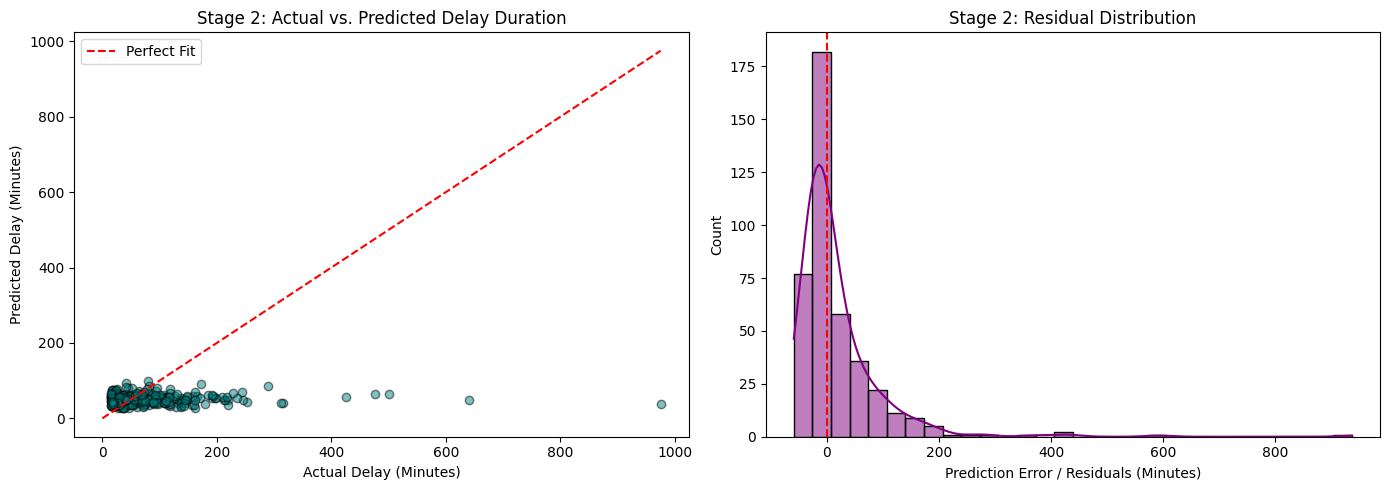

In [30]:
# Create side-by-side visualization plots for Stage 2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs. Predicted Delay Duration
axes[0].scatter(y_test_delayed, y_pred_delayed_tuned, alpha=0.5, color='teal', edgecolors='k')
max_val = max(y_test_delayed.max(), y_pred_delayed_tuned.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', label='Perfect Fit')
axes[0].set_xlabel('Actual Delay (Minutes)')
axes[0].set_ylabel('Predicted Delay (Minutes)')
axes[0].set_title('Stage 2: Actual vs. Predicted Delay Duration')
axes[0].legend()

# Plot 2: Residuals Distribution
residuals = y_test_delayed - y_pred_delayed_tuned
sns.histplot(residuals, kde=True, ax=axes[1], color='purple', bins=30)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Prediction Error / Residuals (Minutes)')
axes[1].set_ylabel('Count')
axes[1].set_title('Stage 2: Residual Distribution')

plt.tight_layout()
plt.show()